# Weekly Project 03 - Multiple View Geometry 1

## Implementation of stereo block matching

This week you'll be implementing your own block matching algorithm for stereo depth reconstruction. Thus you are not allowed to use cv2.matchTemplate, cv2.stereoBM or similar functions from opencv or other pre-existing libraries. You can find all necessary image-files in the attached zip-file.

It is recommended you use the following three intermediate steps before going directly to a full implementation:

### Intermediate step 1:

Implement a function that takes two equal size images and calculates the sum of absolute differences. The two equal-sized images are nose_left.png (used as the template) and nose_right.png.

### Intermediate step 2:

Using the function you just created, find which of the three images nose1.png, nose2.png, nose3.png gives the best match to nose_left.png?

### Intermediate step 3:

Since these images are rectified, we can approximately assume that a pixel found in row x in the left image also lives in row x in the right image. nose_span.png contains the entire row containing the nose of the sculpture. The height of the span is 7 - the same height as your template. Write a function that loops through the image from left to right and computes the correlation using your function from step 1 to find where in the span the nose is located.

### Full template matching implementation (Challenge):

Write a template matching function that iteratively takes a 7x7 subpart (numpy calls this slicing) of tsukuba_left.png and uses your function from step 3 to apply it to the corresponding row in tsukuba_right.png and stores the lowest/best matching disparity value for that template. Continue until all possible templates for a row has been used before moving down to the next row in the image.

## Weekly Project 03 - Start Here

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

### Intermediate step 1:

The sum of absolute differences (SAD) is a dissimilarity measure between two image patches $I_1$ and $I_2$ of equal size.

A value of 0 means that the patches are identical, and a lower value indicates a better match.

- Both images are loaded as single-channel grayscale images, so each pixel is represented by one intensity value in the range 0–255. The nose images are stored as grayscale. We observed that loading them with the default colour flag would replicate the channel three times and triple the SAD without adding any information, so we decided to grayscale them first.
- We created a function called `sad` to calculate the sum of asbolute differences. It subtracts pixel intensities from two images and returns the absolute value.

nose_left shape: (7, 7)
nose_right shape: (7, 7)
sum of absolute difference (nose_left, nose_right) = 7657


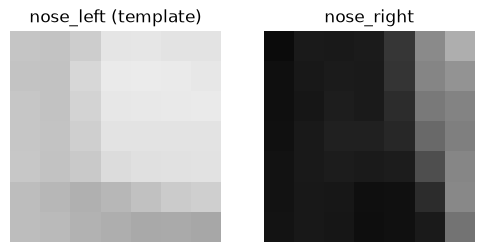

In [2]:
def sad(image1, image2):
    """Sum of absolute differences between two equal-sized images."""
    if image1.shape != image2.shape:
        raise ValueError(f"Shapes differ: {image1.shape} vs {image2.shape}")
    # uint8 subtraction wraps around (e.g. 10 - 20 = 246), so cast to a signed type first
    diff = image1.astype(np.int32) - image2.astype(np.int32)
    return int(np.sum(np.abs(diff)))


nose_left = cv2.imread("nose_left.png", cv2.IMREAD_GRAYSCALE)
nose_right = cv2.imread("nose_right.png", cv2.IMREAD_GRAYSCALE)

print("nose_left shape:", nose_left.shape)
print("nose_right shape:", nose_right.shape)
print("sum of absolute difference (nose_left, nose_right) =", sad(nose_left, nose_right))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, img, title in zip(axes, [nose_left, nose_right], ["nose_left (template)", "nose_right"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()

As seen in the figure, `nose_left.png` is mostly bright while `nose_right.png` is mostly dark, which indicates that the two patches do not show the same part of the scene. That is the reason why the SAD between `nose_left.png` and `nose_right.png` is 7657.

### Intermediate step 2:

- The SAD function from step 1 is evaluated between the template `nose_left.png` and each of the candidates `nose1.png`, `nose2.png` and `nose3.png`.
- Since the SAD is a dissimilarity measure, the best match is the candidate with the lowest SAD. The minimum is tracked while iterating over the candidates.

sum of absolute difference (nose_left, nose1) = 1361
sum of absolute difference (nose_left, nose2) = 119
sum of absolute difference (nose_left, nose3) = 1490
Best match is the one with the lowest SAD value: nose2 with SAD = 119


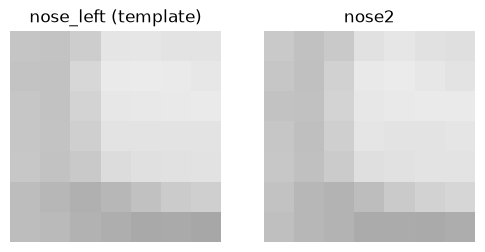

In [3]:
best_sad = float("inf")
best_index = None
best_img = None
for i in range(1, 4):
    img = cv2.imread(f"nose{i}.png", cv2.IMREAD_GRAYSCALE)
    curr_sad = sad(nose_left, img)
    print(f"sum of absolute difference (nose_left, nose{i}) =", curr_sad)
    # SAD is a dissimilarity measure, so the best match has the lowest value
    if curr_sad < best_sad:
        best_sad = curr_sad
        best_img = img
        best_index = i

print(f"Best match is the one with the lowest SAD value: nose{best_index} with SAD = {best_sad}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, img, title in zip(axes, [nose_left, best_img], ["nose_left (template)", f"nose{best_index}"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()

`nose2.png` is the best match to `nose_left.png`. Its SAD is approximately an order of magnitude lower than those of the other two candidates, and the two patches are visually almost indistinguishable.

### Intermediate step 3:

Since the image pair is rectified, the point corresponding to the template lies in the same rows of the right image, which reduces the search to one dimension.

- A window of the same size as the template (7 × 7) is slid along `nose_span.png` one column at a time. For a window with its left edge at column $x$, the window covers columns $x$ to $x + 6$.
- The SAD between the template and each window is computed with the function from step 1, and all scores are stored. The position of the minimum SAD is taken as the location of the nose.
- Positions are reported as the left edge of the window. The centre of the window is at $x + \lfloor 7/2 \rfloor = x + 3$.

nose_span shape: (7, 384)
number of positions checked: 378
Best match: left edge x = 132, center x = 135, SAD = 119


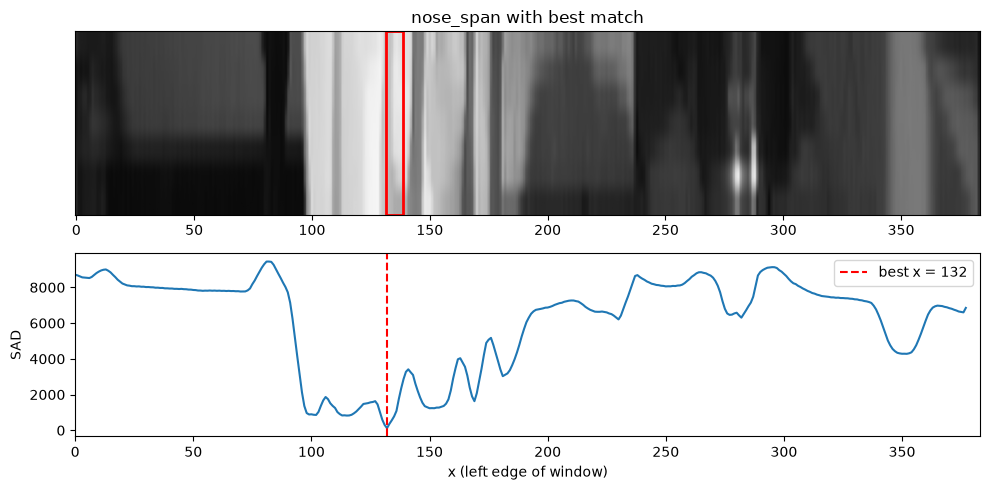

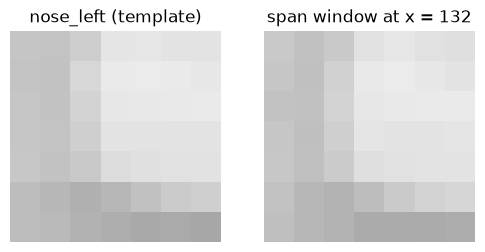

In [4]:
def find_best_match(template, span):
    """Slide template left to right along span.

    Returns the best x (left edge of the window) and the SAD score at every x.
    """
    t_h, t_w = template.shape
    s_h, s_w = span.shape
    if t_h != s_h:
        raise ValueError(f"Heights differ: template {t_h} vs span {s_h}")
    if t_w > s_w:
        raise ValueError(f"Template width {t_w} is larger than span width {s_w}")
    scores = []
    # The last valid left edge is s_w - t_w, hence the + 1
    for x in range(s_w - t_w + 1):
        window = span[:, x:x + t_w]
        scores.append(sad(template, window))

    scores = np.array(scores)
    best_x = int(np.argmin(scores))
    return best_x, scores


nose_span = cv2.imread("nose_span.png", cv2.IMREAD_GRAYSCALE)
best_x, scores = find_best_match(nose_left, nose_span)
t_h, t_w = nose_left.shape

print("nose_span shape:", nose_span.shape)
print("number of positions checked:", len(scores))
print(f"Best match: left edge x = {best_x}, center x = {best_x + t_w // 2}, SAD = {scores[best_x]}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].imshow(nose_span, cmap="gray", vmin=0, vmax=255, aspect="auto")
# imshow places pixel centres at integer coordinates, so pixel borders lie at -0.5
axes[0].add_patch(plt.Rectangle((best_x - 0.5, -0.5), t_w, t_h, edgecolor="red", fill=False, linewidth=2))
axes[0].set_title("nose_span with best match")
axes[0].set_yticks([])

axes[1].plot(scores)
axes[1].axvline(best_x, color="red", linestyle="--", label=f"best x = {best_x}")
axes[1].set_xlim(0, nose_span.shape[1] - 1)
axes[1].set_xlabel("x (left edge of window)")
axes[1].set_ylabel("SAD")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
best_window = nose_span[:, best_x:best_x + t_w]
for ax, img, title in zip(axes, [nose_left, best_window], ["nose_left (template)", f"span window at x = {best_x}"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()

The SAD curve contains a broad low region between approximately $x = 95$ and $x = 150$, where the span has a similar brightness to the template. The best match is at $x = 132$ (left edge of the window), i.e. the nose is centred at column 135 of the span, with a SAD of 119. We observed that this is identical to the SAD of `nose2.png` in step 2, which indicates that `nose2.png` was cropped from this position of the span.

### Full template matching implementation (Challenge):

The disparity map is computed by repeating step 3 for every 7 × 7 block of the left image.

- For every row $r$ and column $c$ at which a complete block fits, the template is `left[r:r+7, c:c+7]`. The rows are processed from top to bottom, and within each row the templates are processed from left to right. This gives $(288 - 6) \times (384 - 6) = 106\,596$ templates.
- Since the images are rectified, the match is searched for only in the same seven rows of the right image, using `find_best_match` from step 3.
- `find_best_match` returns the position relative to the start of the search strip, so the offset of the strip is added to obtain the column $m$ of the match in the right image. The disparity is then $d = c - m$. The result is the same whether the left edges or the centres of the blocks are used, since both are offset by 3 pixels.
- The disparity is stored at the centre pixel of the template, $(r + 3, c + 3)$, so that the disparity map is aligned with the input image. The 3-pixel border, on which no template can be centred, is left at 0.
- Choice of $d_\text{max}$: The disparity is inversely proportional to depth, $d = fB/Z$, so $d_\text{max}$ determines the closest depth that can be measured. If the true disparity of a pixel exceeds $d_\text{max}$, the correct position is never evaluated, and the best score within the range corresponds to an incorrect match. It is therefore not clamped to $d_\text{max}$ but can take any value in the range. With $d_\text{max} = 16$, the map was dominated by such incorrect matches, and 38 % of the pixels had a disparity exactly at the limit. With $d_\text{max} = 64$, fewer than 1 % of the pixels were at the limit, and increasing it to 96 gave the same disparities for the objects in the scene. $d_\text{max} = 64$ was therefore chosen. We used AI to evaluate different maximum disparity values, because without selecting a maximum value the computational cost was very high and thus the code was slow (around 5 minutes to run), while with the selection of the maximum disparity value the code was significantly faster (around 40 seconds), achieving the same results.

tsukuba shapes: (288, 384) (288, 384)
disparity range: 0 to 64


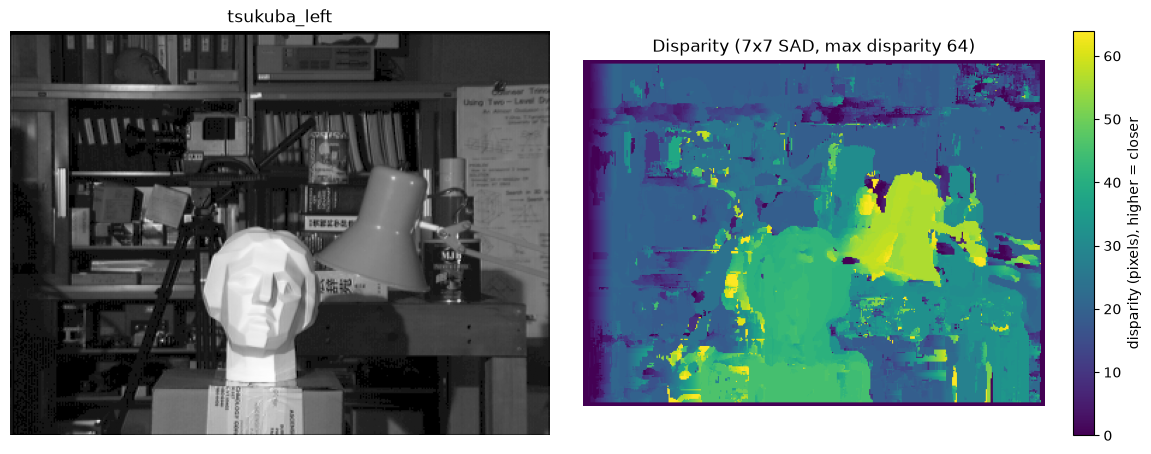

In [5]:
def compute_disparity_map(left, right, block_size=7, max_disparity=64):
    """Block matching: for every block_size x block_size template in left,
    find the best match in the same rows of right using find_best_match.

    The disparity is stored at the template's center pixel. Border pixels
    that no template is centered on stay 0.
    """
    if left.shape != right.shape:
        raise ValueError(f"Shapes differ: {left.shape} vs {right.shape}")
    h, w = left.shape
    half = block_size // 2
    disparity = np.zeros((h, w), dtype=np.int32)

    for r in range(h - block_size + 1):
        right_rows = right[r:r + block_size, :]
        for c in range(w - block_size + 1):
            template = left[r:r + block_size, c:c + block_size]

            # A scene point appears at the same column or further left in the right
            # image, so only left edges from c - max_disparity to c are searched.
            # Since start <= c, the strip is always at least block_size wide.
            start = max(0, c - max_disparity)
            strip = right_rows[:, start:c + block_size]

            best_x, _ = find_best_match(template, strip)
            # best_x is relative to the start of the strip, not the image
            disparity[r + half, c + half] = c - (start + best_x)

    return disparity


tsukuba_left = cv2.imread("tsukuba_left.png", cv2.IMREAD_GRAYSCALE)
tsukuba_right = cv2.imread("tsukuba_right.png", cv2.IMREAD_GRAYSCALE)
print("tsukuba shapes:", tsukuba_left.shape, tsukuba_right.shape)

disparity = compute_disparity_map(tsukuba_left, tsukuba_right, block_size=7, max_disparity=64)
print("disparity range:", disparity.min(), "to", disparity.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(tsukuba_left, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("tsukuba_left")
axes[0].axis("off")

im = axes[1].imshow(disparity, cmap="viridis")
axes[1].set_title("Disparity (7x7 SAD, max disparity 64)")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], label="disparity (pixels), higher = closer")
plt.tight_layout()
plt.show()

### Result and discussion

- The disparity map shows the expected depth ordering. The lamp has the largest disparity (approximately 54 px) and is therefore closest to the cameras, followed by the head and the box (approximately 43–45 px), while the bookshelf in the background has a disparity of approximately 20 px.
- The dark band along the left edge of the map is caused by the clamped search range: a pixel in column $c < d_\text{max}$ can have a disparity of at most $c$. In addition, the part of the scene near the left edge of the left image is not visible in the right image.\
- Incorrect matches appear as sparse dots in regions with little texture and in regions with repetitive structure, such as the bookshelves, since many positions give similar SAD values there. Errors also occur at object boundaries, where the 7 × 7 block contains both foreground and background, and in regions that are occluded in the right image.

### Declaration of AI Usage

- We used AI to optimize the code for the full template matching implementation (Challenge) with the maximum disparity.
- Additionally, we used AI to help us refine the code documentation.